In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [5]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [6]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [7]:
# Split our data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
df.shape

(9568, 5)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [11]:
import torch 
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [12]:
type(X_train_scaled)

numpy.ndarray

In [13]:
type(y_train)
y_train.shape

(7654,)

In [14]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

### Deep Learning

In [15]:
# Define our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            # 1st hiden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # output layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
import torch.optim as optim

model = ANN()

# loss, optimizer
crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [17]:
# Train the ANN

train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = featurs of 1 batch
        # yb = labels for 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute Loss
        loss.backward() # back prop..compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is  a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss
    
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)
    
    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") # .pt or .pth

epoch 1/100 ==> train loss = 205819.13951822917 & val loss = 203693.25
epoch 2/100 ==> train loss = 196387.90266927084 & val loss = 183938.578125
epoch 3/100 ==> train loss = 161933.72721354166 & val loss = 135593.59375
epoch 4/100 ==> train loss = 104268.86653645833 & val loss = 71347.625
epoch 5/100 ==> train loss = 46859.28973795573 & val loss = 29531.169921875
epoch 6/100 ==> train loss = 23328.700313313802 & val loss = 18982.759765625
epoch 7/100 ==> train loss = 17110.115559895832 & val loss = 14902.859375
epoch 8/100 ==> train loss = 13408.04224243164 & val loss = 11458.9462890625
epoch 9/100 ==> train loss = 10053.54956665039 & val loss = 8335.6865234375
epoch 10/100 ==> train loss = 7210.547072347005 & val loss = 5853.05517578125
epoch 11/100 ==> train loss = 4965.743267822266 & val loss = 3974.4306640625
epoch 12/100 ==> train loss = 3327.644283548991 & val loss = 2626.64453125
epoch 13/100 ==> train loss = 2194.605665588379 & val loss = 1720.5711669921875
epoch 14/100 ==> tr

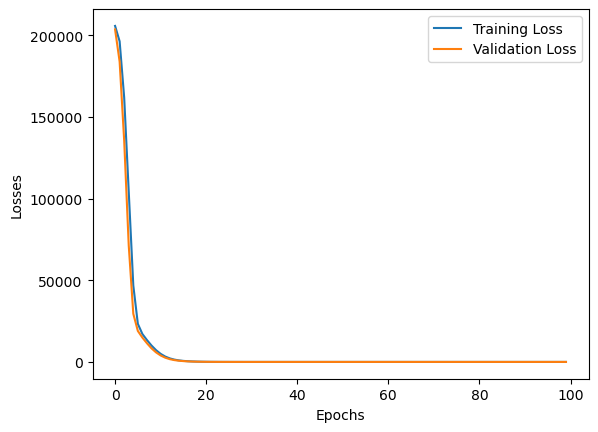

In [18]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [19]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [20]:
# Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = crietrion(train_preds, y_train_tensor)
    test_mse_loss = crietrion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.710968017578125
Testing MSE: 18.906837463378906


In [21]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9339254815752951


In [22]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.166931,433.27
1,436.861969,438.16
2,461.117737,458.42
3,475.946442,480.82
4,435.324646,441.41
...,...,...
1909,451.140930,456.70
1910,431.602020,438.04
1911,467.195068,467.80
1912,431.049927,437.14


### Machine Learning

In [23]:
# Linear Regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

print("r^2 score:", r2_score(y_test, y_pred))

r^2 score: 0.9314747936670361


In [24]:
# KNN

from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor()

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("r^2 score:", r2_score(y_test, y_pred))

r^2 score: 0.9521517965621104


In [25]:
# SVM

from sklearn.svm import SVR

svr = SVR()

svr.fit(X_train_scaled, y_train)

y_pred = svr.predict(X_test_scaled)

print("r^2 score:", r2_score(y_test, y_pred))

r^2 score: 0.943254533099243


In [26]:
# Decision Tree

from sklearn.tree import DecisionTreeRegressor

dtr = DecisionTreeRegressor()

dtr.fit(X_train, y_train)

y_pred = dtr.predict(X_test)

print("r^2 score:", r2_score(y_test, y_pred))

r^2 score: 0.9278808678437325


In [27]:
# Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("r^2 score:", r2_score(y_test, y_pred))

r^2 score: 0.9648766200836006


In [28]:
# Voting

from sklearn.ensemble import VotingRegressor

vr = VotingRegressor(
    estimators=[
        ("lr", lr),
        ("dtr", dtr),
        ("svr", svr)
    ]
)

vr.fit(X_train_scaled, y_train)

y_pred = vr.predict(X_test_scaled)

print("r^2 score:", r2_score(y_test, y_pred))

r^2 score: 0.9535672369799043


In [29]:
# Gradient Boosting

from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred = gbr.predict(X_test)

print("r^2 score:", r2_score(y_test, y_pred))

r^2 score: 0.9514707259236108


In [30]:
# Adaboost

from sklearn.ensemble import AdaBoostRegressor

base_model = DecisionTreeRegressor()

abr = AdaBoostRegressor(
    estimator=base_model,
    n_estimators=100,
    random_state=42
)

abr.fit(X_train, y_train)

y_pred = abr.predict(X_test)

print("r^2 score:", r2_score(y_test, y_pred))

r^2 score: 0.9657515842398244


In [31]:
# Xgboost

import xgboost as xgb

xbr = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
)

xbr.fit(X_train, y_train)

y_pred = xbr.predict(X_test)

print("r^2 score:", r2_score(y_test, y_pred))

r^2 score: 0.9503502656652901
